In [2]:
%pip install yfinance

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.0 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 4.1 MB/s  0:00:00
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.1 MB 4.5 MB/s eta 0:00:01
   ------------------ --------------------- 1.8/4.1 MB 4.1 MB/s eta 0:00:01
   ------------------------- -------------- 2.6/4.1 MB 4.0 MB/s eta 0:00:01
   --------------------------------- ------ 3.4/4.1 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 3.9 MB/s  0:00:01

   ---------------------------------------- 0/8 [pytz]
   ---------------------------------------- 0/8 [pytz]
   ---------------------------------------- 0/8 [pytz]
   ---------------------------------------- 0/8 [pytz]
   ---------------------------------------- 0/8 [pytz]
   ---------------------------------------- 0/8 [pytz]
   --


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [4]:
ticker = "TCS.NS"

data = yf.download(
    ticker,
    start="2020-08-22",
    end="2026-08-22",
    auto_adjust=False
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,,
2020-08-24,1927.283081,2248.100098,2259.949951,2230.000000,2250.600098,2167966
2020-08-25,1922.610107,2242.649902,2250.000000,2233.550049,2245.000000,1663419
2020-08-26,1931.911499,2253.500000,2259.899902,2216.449951,2242.000000,2618149
2020-08-27,1927.539795,2248.399902,2287.350098,2241.750000,2266.000000,3579393
2020-08-28,1919.095459,2238.550049,2279.949951,2235.100098,2268.399902,2941136


In [5]:
# Check the dataset
print("Number of rows:", len(data))
print("Number of columns:", len(data.columns))

data.info()

Number of rows: 1488
Number of columns: 6
<class 'pandas.DataFrame'>
DatetimeIndex: 1488 entries, 2020-08-24 to 2026-08-21
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Adj Close, TCS.NS)  1488 non-null   float64
 1   (Close, TCS.NS)      1488 non-null   float64
 2   (High, TCS.NS)       1488 non-null   float64
 3   (Low, TCS.NS)        1488 non-null   float64
 4   (Open, TCS.NS)       1488 non-null   float64
 5   (Volume, TCS.NS)     1488 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 81.4 KB


In [6]:
data.to_csv("raw_stock_data.csv")

print("Raw dataset saved successfully!")

Raw dataset saved successfully!


In [7]:
data.columns = data.columns.get_level_values(0)
print(data.columns)

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [8]:
print("Missing values:")
print(data.isnull().sum())

Missing values:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


In [10]:
print("\nDuplicate rows:", data.duplicated().sum()) 


Duplicate rows: 0


In [12]:
data["Daily_Return"] = data["Close"].pct_change()

data["MA_7"] = data["Close"].rolling(window=7).mean()

data["MA_21"] = data["Close"].rolling(window=21).mean()

data["Volatility_7"] = data["Daily_Return"].rolling(window=7).std()

data["Volume_Change"] = data["Volume"].pct_change()

data["Target"] = (data["Close"].shift(-1) > data["Close"]).astype(int)

data.head(10)

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return,MA_7,MA_21,Volatility_7,Volume_Change,Target
Date,,,,,,,,,,,,
2020-08-24,1927.283081,2248.100098,2259.949951,2230.000000,2250.600098,2167966,NaN,NaN,NaN,NaN,NaN,0
2020-08-25,1922.610107,2242.649902,2250.000000,2233.550049,2245.000000,1663419,-0.002424,NaN,NaN,NaN,-0.232728,1
2020-08-26,1931.911499,2253.500000,2259.899902,2216.449951,2242.000000,2618149,0.004838,NaN,NaN,NaN,0.573956,0
2020-08-27,1927.539795,2248.399902,2287.350098,2241.750000,2266.000000,3579393,-0.002263,NaN,NaN,NaN,0.367146,0
2020-08-28,1919.095459,2238.550049,2279.949951,2235.100098,2268.399902,2941136,-0.004381,NaN,NaN,NaN,-0.178314,1
2020-08-31,1935.126465,2257.250000,2276.199951,2228.000000,2240.000000,6018154,0.008354,NaN,NaN,NaN,1.046201,0
2020-09-01,1925.782593,2246.350098,2278.000000,2241.300049,2269.000000,3610908,-0.004829,2247.828578,NaN,NaN,-0.399997,1
2020-09-02,1941.899292,2265.149902,2268.750000,2241.649902,2247.000000,2084137,0.008369,2250.264265,NaN,0.005893,-0.422822,1
2020-09-03,1971.347168,2299.500000,2324.000000,2268.000000,2268.000000,4654146,0.015165,2258.385707,NaN,0.007635,1.233129,0


In [13]:
data = data.dropna()

print("Rows after feature engineering:", len(data))
print("Missing values remaining:", data.isnull().sum().sum())

data.head()

Rows after feature engineering: 1468
Missing values remaining: 0


Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return,MA_7,MA_21,Volatility_7,Volume_Change,Target
Date,,,,,,,,,,,,
2020-09-21,2113.486816,2465.300049,2504.899902,2452.149902,2465.0,4598809,0.006286,2462.292829,2340.873791,0.021103,0.099337,1
2020-09-22,2162.910156,2522.949951,2555.000000,2458.000000,2485.0,7499613,0.023385,2483.557094,2353.961879,0.021581,0.630773,0
2020-09-23,2115.330322,2467.449951,2519.850098,2409.000000,2510.0,7502280,-0.021998,2480.135672,2364.666643,0.015182,0.000356,0
2020-09-24,1999.423828,2332.250000,2450.000000,2302.600098,2450.0,8424708,-0.054793,2457.399972,2368.416643,0.025219,0.122953,1
2020-09-25,2076.623535,2422.300049,2440.000000,2352.100098,2368.0,8228267,0.038611,2445.871408,2376.697603,0.030927,-0.023317,1


In [14]:
data.to_csv("processed_stock_data.csv")

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


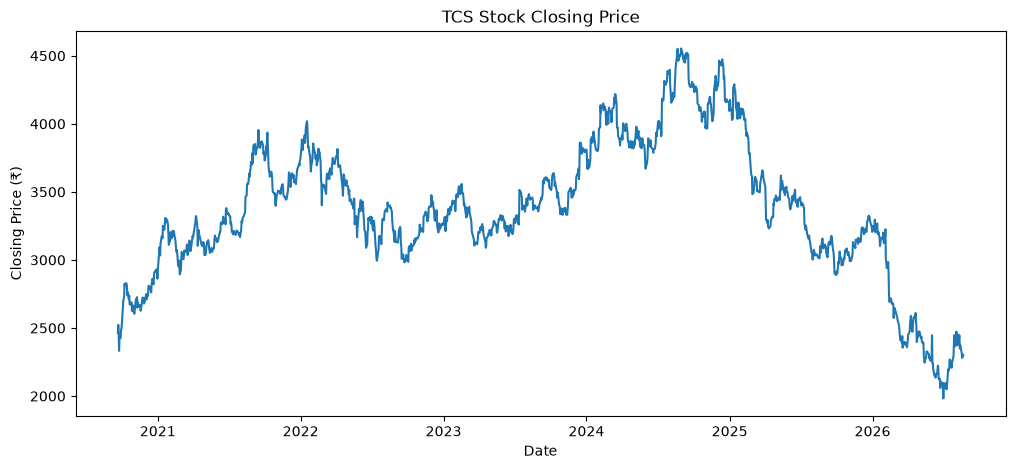

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Close"])
plt.title("TCS Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")

plt.show()

In [16]:
print("Final dataset shape:", data.shape)
print("\nFinal columns:")
print(data.columns.tolist())

print("\nFirst 5 rows:")
display(data.head())

Final dataset shape: (1468, 12)

Final columns:
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'MA_7', 'MA_21', 'Volatility_7', 'Volume_Change', 'Target']

First 5 rows:


Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return,MA_7,MA_21,Volatility_7,Volume_Change,Target
Date,,,,,,,,,,,,
2020-09-21,2113.486816,2465.300049,2504.899902,2452.149902,2465.0,4598809,0.006286,2462.292829,2340.873791,0.021103,0.099337,1
2020-09-22,2162.910156,2522.949951,2555.000000,2458.000000,2485.0,7499613,0.023385,2483.557094,2353.961879,0.021581,0.630773,0
2020-09-23,2115.330322,2467.449951,2519.850098,2409.000000,2510.0,7502280,-0.021998,2480.135672,2364.666643,0.015182,0.000356,0
2020-09-24,1999.423828,2332.250000,2450.000000,2302.600098,2450.0,8424708,-0.054793,2457.399972,2368.416643,0.025219,0.122953,1
2020-09-25,2076.623535,2422.300049,2440.000000,2352.100098,2368.0,8228267,0.038611,2445.871408,2376.697603,0.030927,-0.023317,1


In [17]:
data.to_csv("processed_stock_data.csv")

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
